# Text associations

Associations between normalized reading times on the **text regions**
(distractor / critical / outside) and on the **answers & question**
(A / B / C / D / question), for RT and TFD.

All of the computation lives in `src/statistics/RT_correlations/`:

| module | what |
| --- | --- |
| `columns` | which columns form the rows/cols of a map, and their labels |
| `data` | loading the all-participants and per-group feature frames |
| `correlations` | the maps: pooled r, and per-participant r tested against 0 |
| `comparisons` | cells against each other, and groups against groups |
| `bootstrap` | cluster bootstrap of the pooled r |
| `plots` | annotated heatmaps and tidy tables |
| `report` | the one-call helpers used below |

Data: `L1_model_ready_all_features.csv` (`READY_ALL_FEATURES_PATH`), plus the
per-group files built on first use by `load_group_features()`.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.data_paths import READY_ALL_FEATURES_PATH
from src.statistics.RT_correlations import (
    load_all_features,
    load_group_features,
    metric_map_stats,
    group_map_stats,
    plot_maps,
    plot_pooled_maps,
    shared_vmax,
    plot_contrasts,
    summarise_map,
    region_contrasts,
    reference_contrasts,
    group_contrast,
    compare_cells,
    bootstrap_maps,
    group_bootstrap_maps,
    plot_bootstrap_maps,
    map_cell,
)

# Cached model-ready features; pass rebuild=True to regenerate them from the
# processed CSVs.
df = load_all_features()
group_dfs = load_group_features()

all: (19436, 214)
hunters: (9719, 214)
gatherers: (9717, 214)


## The maps, as originally plotted

Plain pooled Pearson r over all ~19k trials, fixed [-1, 1] colour scale. Kept
for reference -- everything below argues that this view is misleading on both
counts.

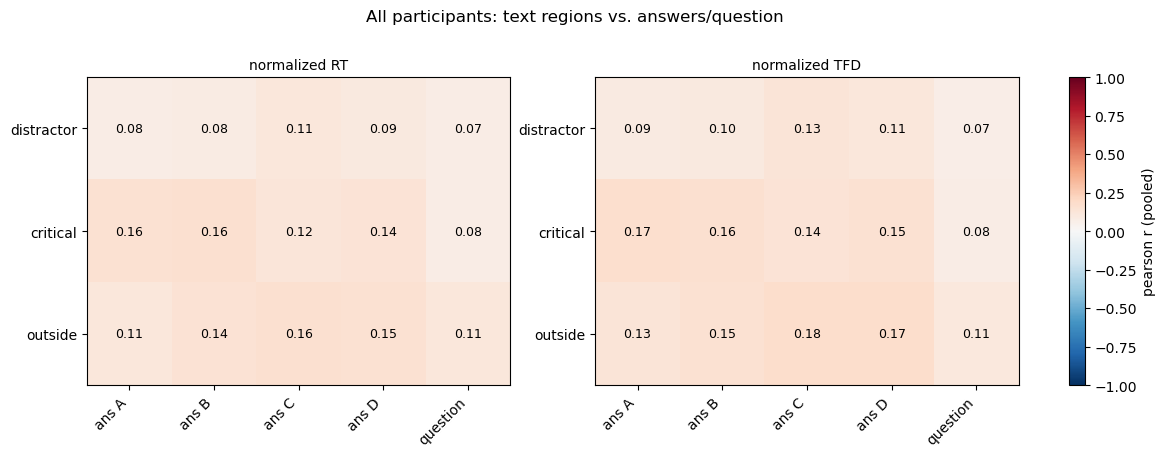

(<Figure size 1300x400 with 3 Axes>,
 array([<Axes: title={'center': 'normalized RT'}>,
        <Axes: title={'center': 'normalized TFD'}>], dtype=object))

In [3]:
plot_pooled_maps(df, "All participants", method="pearson")

## Significance

Trials are nested in participants (360 x 54) and in texts, so a p-value that
assumes ~19k independent rows would call r = 0.014 significant; the effective n
is closer to the number of participants. The tests use the **participant as the
unit of analysis**:

| question | test | function |
| --- | --- | --- |
| is a cell different from 0? | per-participant r -> Fisher z -> one-sample t-test across the 360 participants | `metric_map_stats` |
| are two cells different from each other? | paired t-test on the within-participant difference of z (the pairing absorbs the dependence between two correlations that share a variable, which Steiger's / Williams' test handles for i.i.d. data) | `region_contrasts`, `compare_cells` |
| do hunters and gatherers differ? | Welch two-sample t-test on the per-participant z (disjoint sets of 180 participants) | `group_contrast` |

p-values are Benjamini-Hochberg corrected across the 15 cells of a map. The
default is Spearman: the per-word RTs have skew up to ~40, so Pearson is driven
by a handful of outlier trials.

The estimand also changes. `r_pooled` mixes within- and between-participant
variance -- part of it is just "some people read slowly everywhere". The
participant-level `r` is the within-participant association, and it runs about
half the pooled value here.

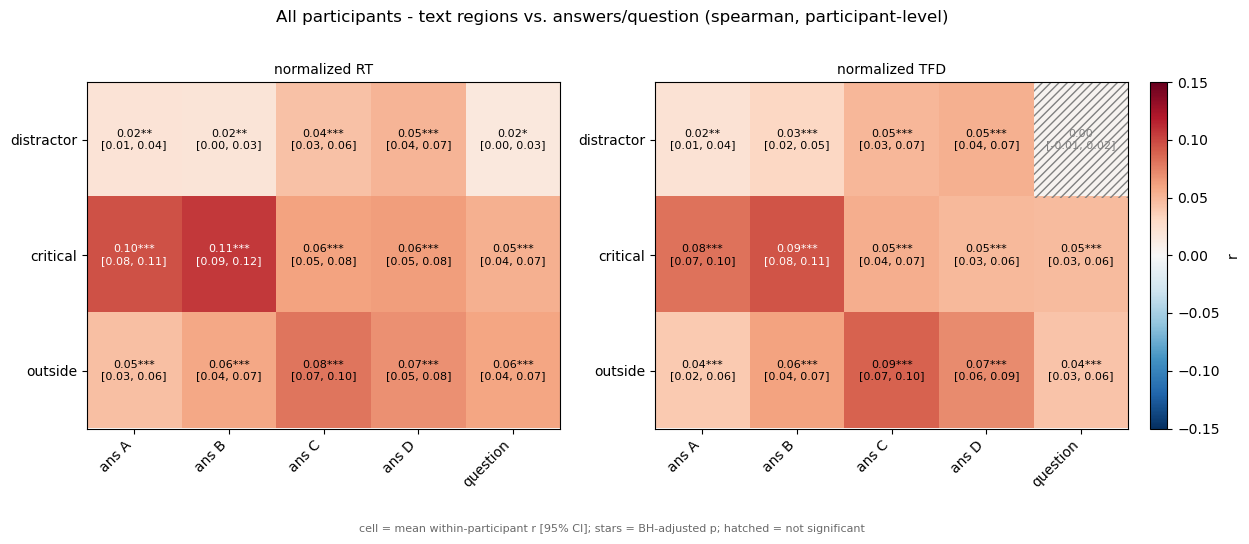

(<Figure size 1400x450 with 3 Axes>,
 array([<Axes: title={'center': 'normalized RT'}>,
        <Axes: title={'center': 'normalized TFD'}>], dtype=object))

In [4]:
stats_all = metric_map_stats(df)          # {"RT": {...}, "TFD": {...}}, spearman
plot_maps(stats_all, "All participants", show_ci=True)

In [5]:
# Per-cell numbers behind the map: participant-level r with CI, effect size, t,
# p, BH-adjusted p, and the pooled r for comparison.
summarise_map(stats_all["RT"]).round(4)

,row,col,n,r,ci_low,ci_high,d,t,p,p_adj,stars,r_pooled
0,critical,ans B,360,0.1055,0.0905,0.1205,0.7234,13.7265,0.0000,0.0000,***,0.2135
1,critical,ans A,360,0.0951,0.0803,0.1099,0.6634,12.5880,0.0000,0.0000,***,0.2260
2,outside,ans C,360,0.0804,0.0652,0.0955,0.5483,10.4033,0.0000,0.0000,***,0.2418
3,outside,ans D,360,0.0683,0.0528,0.0838,0.4555,8.6434,0.0000,0.0000,***,0.2367
4,critical,ans C,360,0.0609,0.0463,0.0754,0.4328,8.2111,0.0000,0.0000,***,0.1832
5,critical,ans D,360,0.0628,0.0474,0.0781,0.4236,8.0380,0.0000,0.0000,***,0.1997
6,outside,ans B,360,0.0582,0.0431,0.0732,0.3989,7.5695,0.0000,0.0000,***,0.2206
7,outside,question,360,0.0588,0.0430,0.0745,0.3861,7.3263,0.0000,0.0000,***,0.0922
8,critical,question,360,0.0532,0.0375,0.0688,0.3522,6.6819,0.0000,0.0000,***,0.0848
9,distractor,ans D,360,0.0506,0.0353,0.0659,0.3421,6.4907,0.0000,0.0000,***,0.1774


### Cells against each other

`region_contrasts` runs the structured set -- within each answer/question
column, the three text regions pairwise (15 tests, rather than all 105
unordered pairs of the map).

In [6]:
region_contrasts(stats_all, "RT").round(4)

,cell_a,cell_b,n,r_a,r_b,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,RT_normalized_distractor ~ RT_normalized_answer_B,RT_normalized_critical ~ RT_normalized_answer_B,360,0.0199,0.1055,-0.0857,-0.0861,-0.1059,-0.0663,-8.5463,0.0000,-0.4504,0.0000,True,***
1,RT_normalized_distractor ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_A,360,0.0208,0.0951,-0.0743,-0.0746,-0.0941,-0.0552,-7.5567,0.0000,-0.3983,0.0000,True,***
2,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_outside ~ RT_normalized_answer_A,360,0.0951,0.0456,0.0496,0.0498,0.0300,0.0696,4.9512,0.0000,0.2610,0.0000,True,***
3,RT_normalized_critical ~ RT_normalized_answer_B,RT_normalized_outside ~ RT_normalized_answer_B,360,0.1055,0.0582,0.0474,0.0477,0.0289,0.0665,4.9794,0.0000,0.2624,0.0000,True,***
4,RT_normalized_distractor ~ RT_normalized_question,RT_normalized_outside ~ RT_normalized_question,360,0.0163,0.0588,-0.0425,-0.0425,-0.0604,-0.0247,-4.6890,0.0000,-0.2471,0.0000,True,***
5,RT_normalized_distractor ~ RT_normalized_answer_C,RT_normalized_outside ~ RT_normalized_answer_C,360,0.0436,0.0804,-0.0368,-0.0369,-0.0535,-0.0204,-4.3990,0.0000,-0.2318,0.0000,True,***
6,RT_normalized_distractor ~ RT_normalized_answer_B,RT_normalized_outside ~ RT_normalized_answer_B,360,0.0199,0.0582,-0.0383,-0.0384,-0.0560,-0.0207,-4.2742,0.0000,-0.2253,0.0001,True,***
7,RT_normalized_distractor ~ RT_normalized_question,RT_normalized_critical ~ RT_normalized_question,360,0.0163,0.0532,-0.0369,-0.0369,-0.0574,-0.0164,-3.5411,0.0005,-0.1866,0.0008,True,***
8,RT_normalized_distractor ~ RT_normalized_answer_A,RT_normalized_outside ~ RT_normalized_answer_A,360,0.0208,0.0456,-0.0248,-0.0248,-0.0424,-0.0071,-2.7630,0.0060,-0.1456,0.0100,True,*
9,RT_normalized_critical ~ RT_normalized_answer_C,RT_normalized_outside ~ RT_normalized_answer_C,360,0.0609,0.0804,-0.0195,-0.0196,-0.0383,-0.0009,-2.0636,0.0398,-0.1088,0.0555,False,.


In [7]:
# Arbitrary pairs, when a specific comparison is the point.
compare_cells(
    stats_all["RT"]["z"],
    [
        (map_cell("critical", "answer_A"), map_cell("critical", "question")),
        (map_cell("critical", "answer_A"), map_cell("distractor", "answer_D")),
    ],
).round(4)

,cell_a,cell_b,n,r_a,r_b,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_question,360,0.0951,0.0532,0.0419,0.0422,0.0223,0.0620,4.1781,0.0,0.2202,0.0,True,***
1,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_distractor ~ RT_normalized_answer_D,360,0.0951,0.0506,0.0446,0.0448,0.0245,0.0651,4.3391,0.0,0.2287,0.0,True,***


### Hunters vs. gatherers

Same maps per group, then a between-group test of every cell.

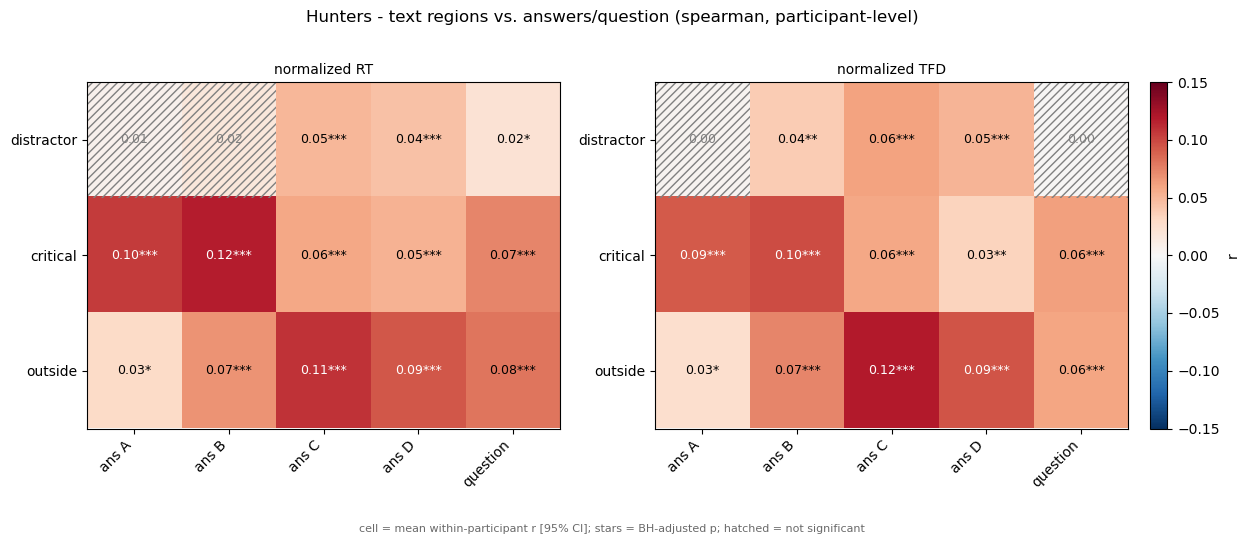

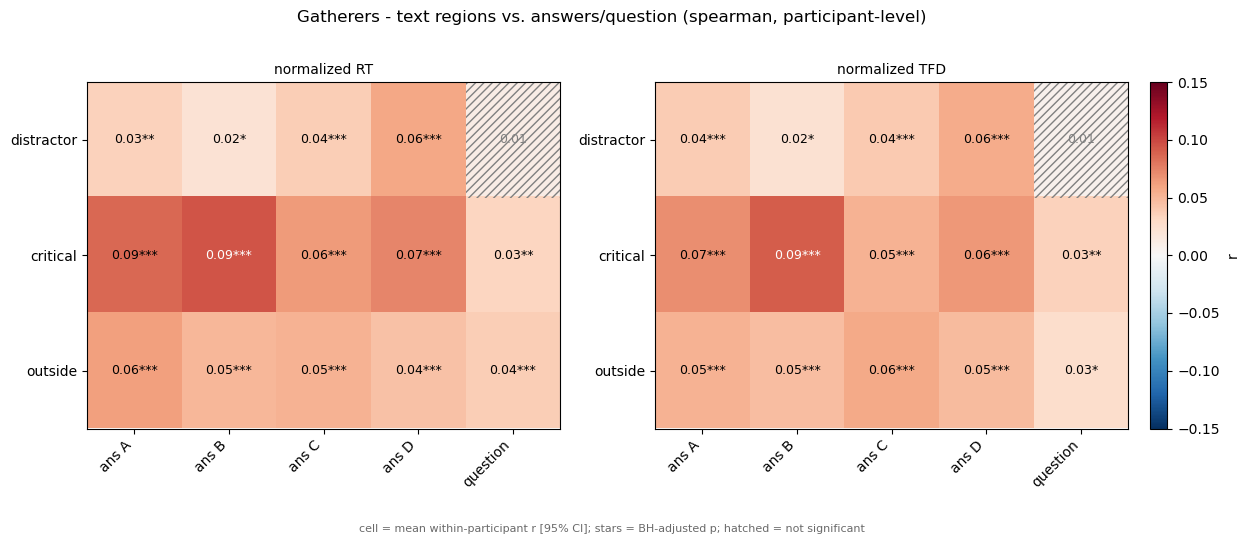

In [8]:
stats_by_group = group_map_stats(group_dfs)

# One colour scale across both figures, otherwise each auto-scales to its own
# range and the same colour means different things in the two.
vmax = shared_vmax(stats_by_group)
for name, st in stats_by_group.items():
    plot_maps(st, name.capitalize(), vmax=vmax)

In [9]:
group_contrast(stats_by_group, "RT").round(4)

,row,col,n_hunters,n_gatherers,r_hunters,r_gatherers,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,RT_normalized_distractor,RT_normalized_answer_A,180,180,0.0069,0.0346,-0.0277,-0.0277,-0.0573,0.0018,-1.8469,0.0656,-0.1947,0.1640,False,
1,RT_normalized_distractor,RT_normalized_answer_B,180,180,0.0175,0.0222,-0.0047,-0.0047,-0.0346,0.0252,-0.3084,0.7579,-0.0325,0.7579,False,
2,RT_normalized_distractor,RT_normalized_answer_C,180,180,0.0501,0.0370,0.0130,0.0131,-0.0173,0.0434,0.8455,0.3984,0.0891,0.4980,False,
3,RT_normalized_distractor,RT_normalized_answer_D,180,180,0.0435,0.0576,-0.0141,-0.0142,-0.0448,0.0165,-0.9081,0.3644,-0.0957,0.4969,False,
4,RT_normalized_distractor,RT_normalized_question,180,180,0.0215,0.0112,0.0103,0.0103,-0.0200,0.0405,0.6683,0.5044,0.0704,0.5820,False,
5,RT_normalized_critical,RT_normalized_answer_A,180,180,0.1045,0.0857,0.0188,0.0190,-0.0108,0.0488,1.2528,0.2111,0.1321,0.3518,False,
6,RT_normalized_critical,RT_normalized_answer_B,180,180,0.1172,0.0938,0.0234,0.0237,-0.0066,0.0540,1.5362,0.1254,0.1619,0.2687,False,
7,RT_normalized_critical,RT_normalized_answer_C,180,180,0.0576,0.0641,-0.0065,-0.0065,-0.0358,0.0227,-0.4402,0.6601,-0.0464,0.7072,False,
8,RT_normalized_critical,RT_normalized_answer_D,180,180,0.0525,0.0730,-0.0204,-0.0205,-0.0512,0.0102,-1.3132,0.1900,-0.1384,0.3518,False,
9,RT_normalized_critical,RT_normalized_question,180,180,0.0736,0.0327,0.0410,0.0411,0.0100,0.0722,2.5998,0.0097,0.2740,0.0364,True,*


### Robustness: the pooled r with a corrected standard error

Keeps the pooled r that the first maps show as the estimand and fixes only its
uncertainty, by resampling participants (not trials) with replacement. If a cell
survives here as well as in the participant-level map above, it is not an
artefact of either choice of estimand.

Slower than the rest -- about 30 s for both metrics at `n_boot=1000`. Note the
bootstrap p cannot resolve below `1 / n_boot`, so read the CIs rather than the
stars here; the participant-level map above is where the p-values are informative.

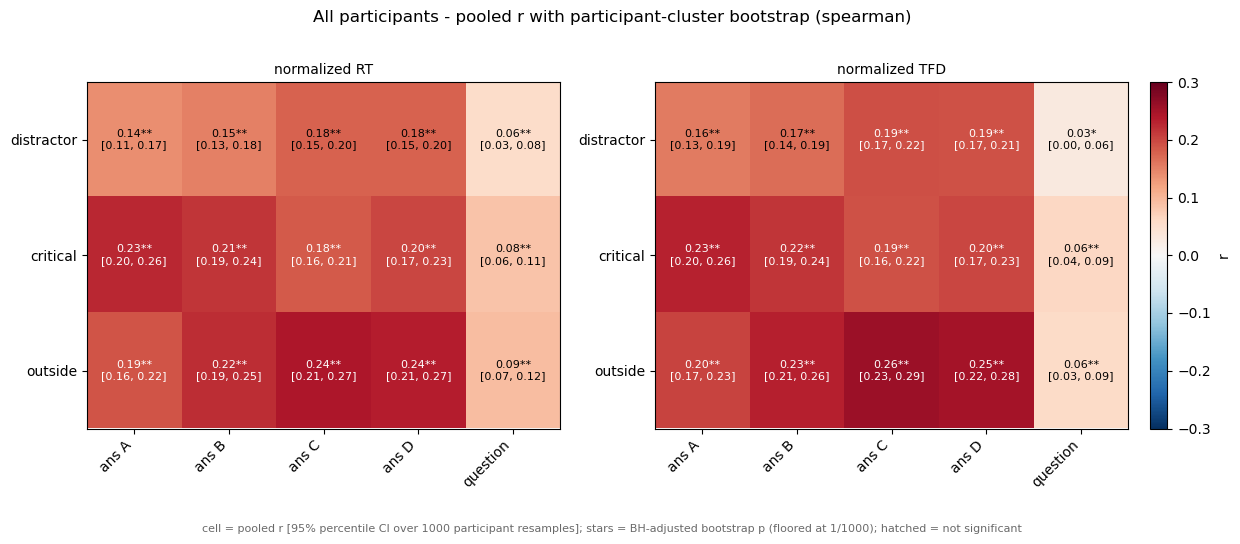

(<Figure size 1400x450 with 3 Axes>,
 array([<Axes: title={'center': 'normalized RT'}>,
        <Axes: title={'center': 'normalized TFD'}>], dtype=object))

In [10]:
boot_all = bootstrap_maps(df, n_boot=1000)
plot_bootstrap_maps(boot_all, "All participants")

In [11]:
summarise_map(boot_all["RT"]).round(4)

,row,col,n,r,ci_low,ci_high,p,p_adj,stars
0,distractor,ans A,360,0.1386,0.1120,0.1680,0.001,0.001,**
1,distractor,ans B,360,0.1511,0.1267,0.1768,0.001,0.001,**
2,distractor,ans C,360,0.1762,0.1511,0.2011,0.001,0.001,**
3,distractor,ans D,360,0.1774,0.1519,0.2020,0.001,0.001,**
4,distractor,question,360,0.0552,0.0324,0.0789,0.001,0.001,**
5,critical,ans A,360,0.2260,0.1977,0.2562,0.001,0.001,**
6,critical,ans B,360,0.2135,0.1891,0.2383,0.001,0.001,**
7,critical,ans C,360,0.1832,0.1579,0.2100,0.001,0.001,**
8,critical,ans D,360,0.1997,0.1743,0.2277,0.001,0.001,**
9,critical,question,360,0.0848,0.0631,0.1086,0.001,0.001,**


#### Per group

Same bootstrap within each reading regime. Half the participants each, so the
intervals come out roughly sqrt(2) wider than the all-participants ones above --
that widening is expected and is not evidence of a weaker effect. Whether a cell
actually *differs* between the groups is `group_contrast` above, not an eyeball
comparison of these two figures.

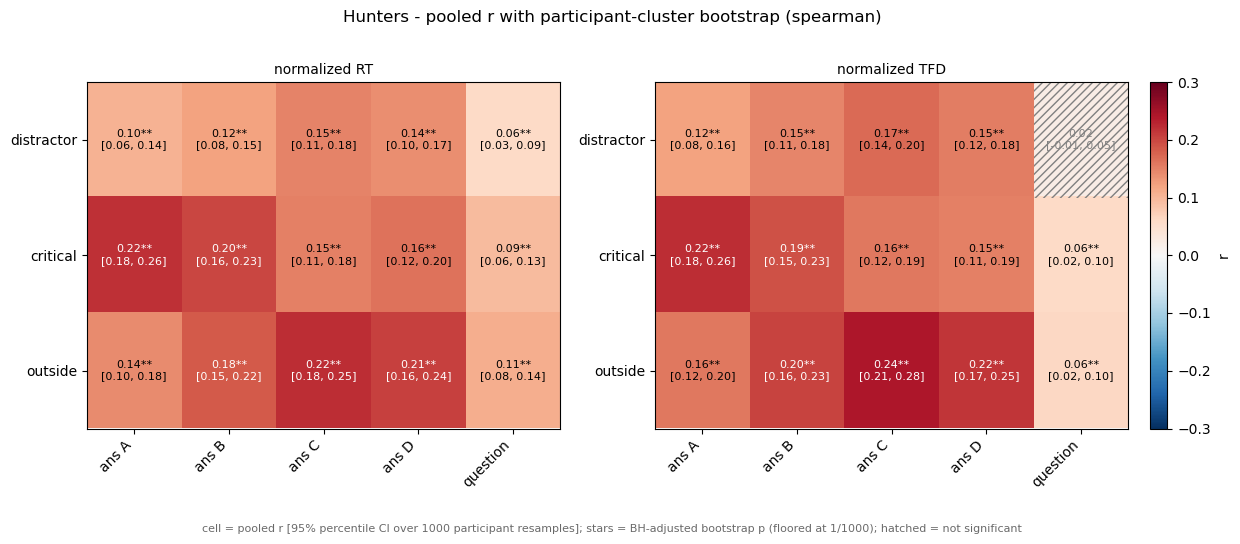

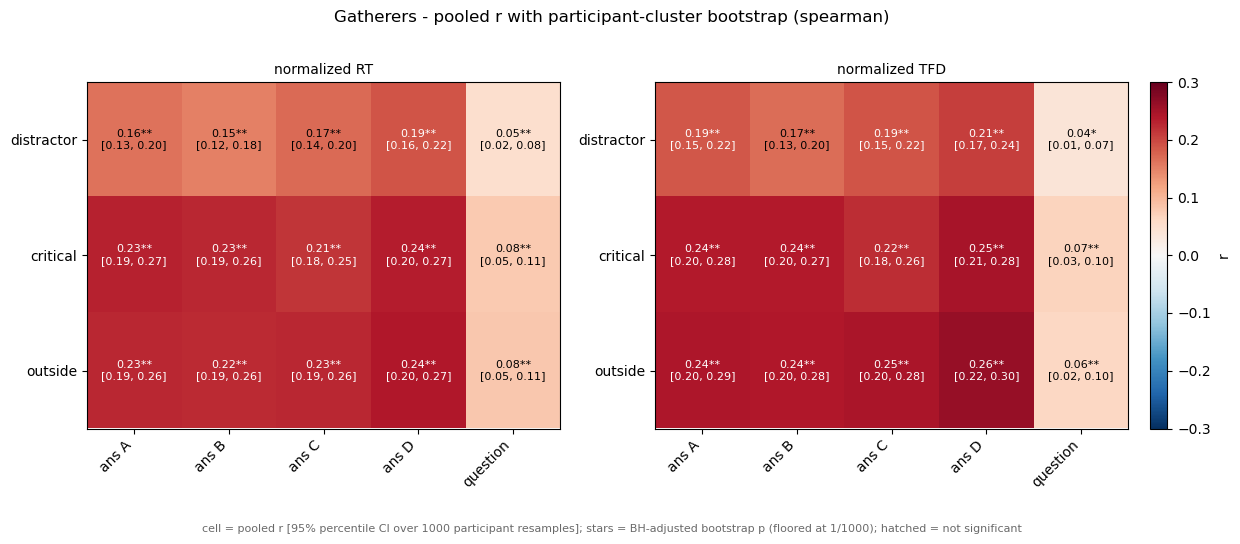

In [12]:
boot_by_group = group_bootstrap_maps(group_dfs, n_boot=1000)

vmax = shared_vmax(boot_by_group)
for name, boot in boot_by_group.items():
    plot_bootstrap_maps(boot, name.capitalize(), vmax=vmax)

## Focus: critical -> answer A

Two questions about the `critical` row specifically, both on the participant-level
Fisher z (the pooled r and its bootstrap are descriptive; these are the tests).

1. Is `critical -> ans A` stronger than `critical -> ` anything else, for all
   participants and within each regime?
2. Do the `critical` effects differ between hunters and gatherers?

Correction is applied within each family separately -- the 4 contrasts of
question 1 per participant set, and the 5 critical cells of question 2 -- rather
than across everything computed in this notebook.

In [13]:
# 1. critical -> ans A against the other answers in the same row.
focus_stats = {"all": stats_all, **stats_by_group}
crit_vs_rest = reference_contrasts(focus_stats, region="critical", answer="answer_A", metric='RT')
crit_vs_rest.round(4)

,label,cell_a,cell_b,n,r_a,r_b,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,all,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_question,360,0.0951,0.0532,0.0419,0.0422,0.0223,0.0620,4.1781,0.0000,0.2202,0.0001,True,***
1,all,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_C,360,0.0951,0.0609,0.0343,0.0345,0.0177,0.0512,4.0480,0.0001,0.2133,0.0001,True,***
2,all,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_D,360,0.0951,0.0628,0.0324,0.0326,0.0159,0.0492,3.8419,0.0001,0.2025,0.0002,True,***
3,all,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_B,360,0.0951,0.1055,-0.0104,-0.0105,-0.0266,0.0056,-1.2863,0.1992,-0.0678,0.1992,False,
4,gatherers,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_question,180,0.0857,0.0327,0.0530,0.0532,0.0254,0.0811,3.7673,0.0002,0.2808,0.0009,True,***
5,gatherers,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_C,180,0.0857,0.0641,0.0216,0.0217,-0.0025,0.0459,1.7680,0.0788,0.1318,0.1575,False,
6,gatherers,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_D,180,0.0857,0.0730,0.0127,0.0128,-0.0118,0.0375,1.0271,0.3058,0.0766,0.4077,False,
7,gatherers,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_B,180,0.0857,0.0938,-0.0081,-0.0082,-0.0314,0.0150,-0.6952,0.4878,-0.0518,0.4878,False,
8,hunters,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_D,180,0.1045,0.0525,0.0520,0.0523,0.0300,0.0746,4.6243,0.0000,0.3447,0.0000,True,***
9,hunters,RT_normalized_critical ~ RT_normalized_answer_A,RT_normalized_critical ~ RT_normalized_answer_C,180,0.1045,0.0576,0.0469,0.0472,0.0240,0.0704,4.0167,0.0001,0.2994,0.0002,True,***


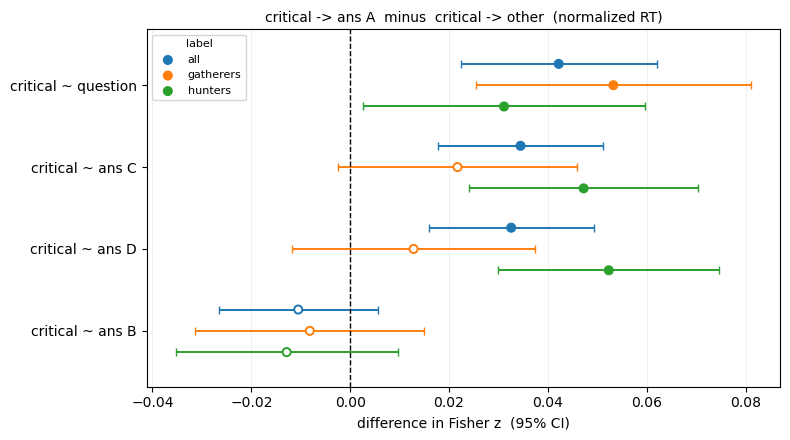

<Axes: title={'center': 'critical -> ans A  minus  critical -> other  (normalized RT)'}, xlabel='difference in Fisher z  (95% CI)'>

In [14]:

# Positive delta = the reference (critical -> ans A) is the stronger correlation.
# Filled marker = the interval clears 0.
plot_contrasts(
    crit_vs_rest,
    title="critical -> ans A  minus  critical -> other  (normalized RT)",
    group_col="label",
    xlabel="difference in Fisher z  (95% CI)",
)

### Do the critical effects differ by regime?

Welch two-sample t-test per cell on the per-participant z, restricted to the
`critical` row so the correction family is those 5 cells.

In [15]:
crit_by_group = group_contrast(stats_by_group, "RT", region="critical")
crit_by_group.round(4)

,row,col,n_hunters,n_gatherers,r_hunters,r_gatherers,delta_r,delta_z,ci_low,ci_high,t,p,d,p_adj,sig,stars
0,RT_normalized_critical,RT_normalized_answer_A,180,180,0.1045,0.0857,0.0188,0.0190,-0.0108,0.0488,1.2528,0.2111,0.1321,0.2639,False,
1,RT_normalized_critical,RT_normalized_answer_B,180,180,0.1172,0.0938,0.0234,0.0237,-0.0066,0.0540,1.5362,0.1254,0.1619,0.2639,False,
2,RT_normalized_critical,RT_normalized_answer_C,180,180,0.0576,0.0641,-0.0065,-0.0065,-0.0358,0.0227,-0.4402,0.6601,-0.0464,0.6601,False,
3,RT_normalized_critical,RT_normalized_answer_D,180,180,0.0525,0.0730,-0.0204,-0.0205,-0.0512,0.0102,-1.3132,0.1900,-0.1384,0.2639,False,
4,RT_normalized_critical,RT_normalized_question,180,180,0.0736,0.0327,0.0410,0.0411,0.0100,0.0722,2.5998,0.0097,0.2740,0.0486,True,*


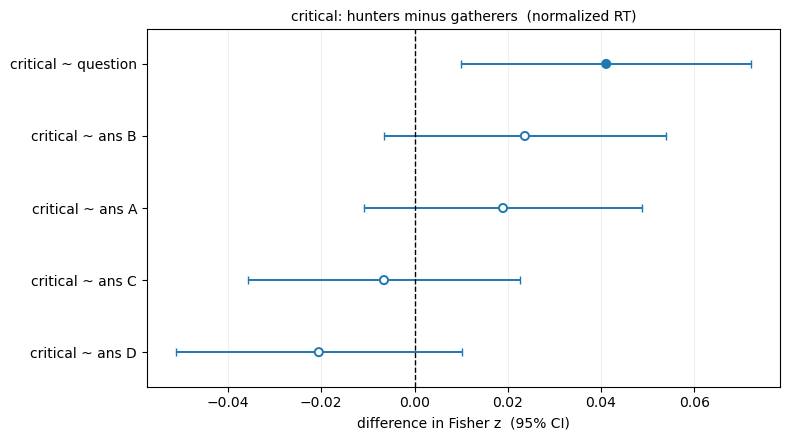

<Axes: title={'center': 'critical: hunters minus gatherers  (normalized RT)'}, xlabel='difference in Fisher z  (95% CI)'>

In [16]:
plot_contrasts(
    crit_by_group,
    title="critical: hunters minus gatherers  (normalized RT)",
    xlabel="difference in Fisher z  (95% CI)",
)

## Predict answer reading times from paragraph features

One regression per answer (A/B/C/D). Predictors are paragraph-only: per-span area
metrics, per-span RT/TFD (pure + normalized), and the hunter/gatherer preview
flag — no answer-area features. Pick `FEATURE_COLS` to control what goes in.

In [16]:
from src.predictive_modeling.answer_RTs.model_data import (
    build_answer_rt_model_df,
    get_paragraph_feature_cols,
    get_span_area_feature_cols,
    get_span_rt_tfd_feature_cols,
    get_preview_feature_cols,
)
from src.predictive_modeling.answer_RTs.run import run_answer_rt_regression

# Trial-level frame: paragraph predictors + answer-RT targets (built once).
answer_rt_model_df = build_answer_rt_model_df()
print("model df:", answer_rt_model_df.shape)


def plot_true_pred(out, answers=("A", "B", "C", "D")):
    """2x2 held-out true-vs-predicted scatter, coloured by reading regime."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    target = out["results"][answers[0]]["metrics"]["target"].rsplit("_answer_", 1)[0]
    for ax, ans in zip(axes.ravel(), answers):
        res = out["results"][ans]
        p, m = res["predictions"], res["metrics"]
        if "question_preview" in p.columns:
            for val, lab, c in [(1, "hunter", "tab:orange"), (0, "gatherer", "tab:blue")]:
                s = p[p["question_preview"] == val]
                ax.scatter(s["y_true"], s["y_pred"], s=6, alpha=0.3, color=c, label=lab)
            ax.legend(fontsize=8)
        else:
            ax.scatter(p["y_true"], p["y_pred"], s=6, alpha=0.3)
        lo = float(min(p["y_true"].min(), p["y_pred"].min()))
        hi = float(max(p["y_true"].max(), p["y_pred"].max()))
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"answer {ans}:  R²={m['r2']:.3f}   RMSE={m['rmse']:.0f}")
        ax.set_xlabel("true RT")
        ax.set_ylabel("predicted RT")
    fig.suptitle(f"True vs predicted — {target}", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_coefs(out, answers=("A", "B", "C", "D"), top_k=12):
    """2x2 top-|coef| standardized coefficients per answer (features are z-scored)."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, ans in zip(axes.ravel(), answers):
        cs = out["results"][ans]["coef_summary"].head(top_k).iloc[::-1]
        colors = ["tab:red" if v < 0 else "tab:green" for v in cs["coef"]]
        ax.barh(cs["feature"], cs["coef"], color=colors)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_title(f"answer {ans} — top {top_k} |coef|")
        ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()


# --- choose which features to run -------------------------------------------
FEATURE_COLS = get_paragraph_feature_cols(answer_rt_model_df)   # everything (default)
# FEATURE_COLS = get_span_rt_tfd_feature_cols(answer_rt_model_df) + get_preview_feature_cols(answer_rt_model_df)
# FEATURE_COLS = get_span_area_feature_cols(answer_rt_model_df)
print("n features chosen:", len(FEATURE_COLS))

model df: (19436, 53)
n features chosen: 43


answer A: R2=0.024 RMSE=352.332 (baseline 356.835) MAE=192.975  [n_train=15549, n_test=3887]
answer B: R2=0.034 RMSE=262.396 (baseline 267.118) MAE=148.359  [n_train=15549, n_test=3887]


answer C: R2=0.042 RMSE=225.748 (baseline 230.700) MAE=124.898  [n_train=15549, n_test=3887]


answer D: R2=0.031 RMSE=209.987 (baseline 213.318) MAE=117.956  [n_train=15549, n_test=3887]


,answer,target,n_train,n_test,n_features,r2,rmse,mae,baseline_rmse
0,A,RT_normalized_answer_A,15549,3887,43,0.024,352.332,192.975,356.835
1,B,RT_normalized_answer_B,15549,3887,43,0.034,262.396,148.359,267.118
2,C,RT_normalized_answer_C,15549,3887,43,0.042,225.748,124.898,230.700
3,D,RT_normalized_answer_D,15549,3887,43,0.031,209.987,117.956,213.318


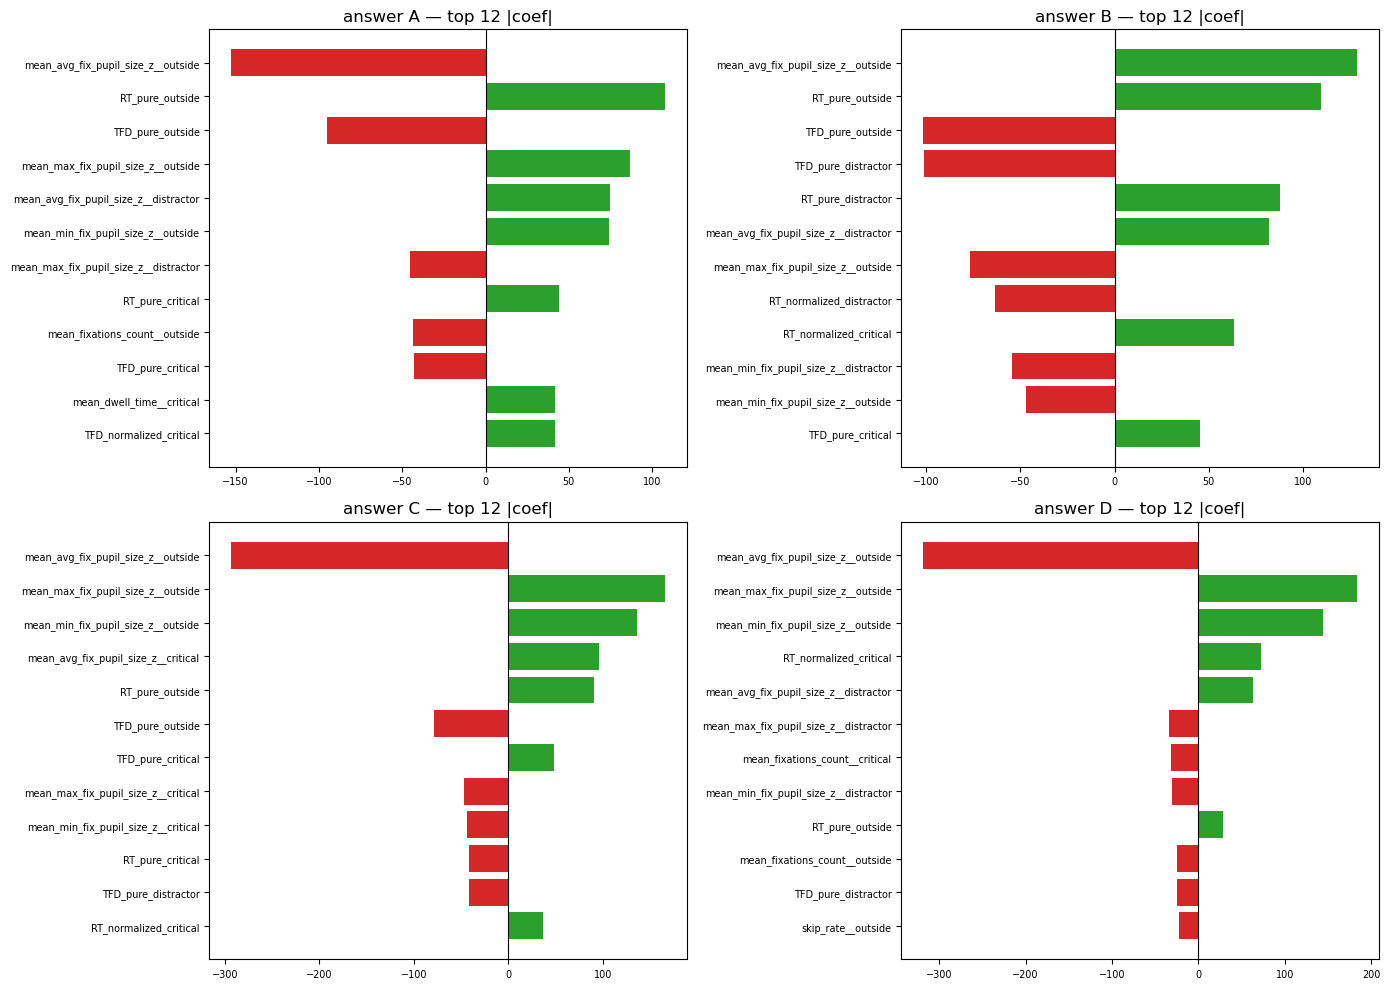

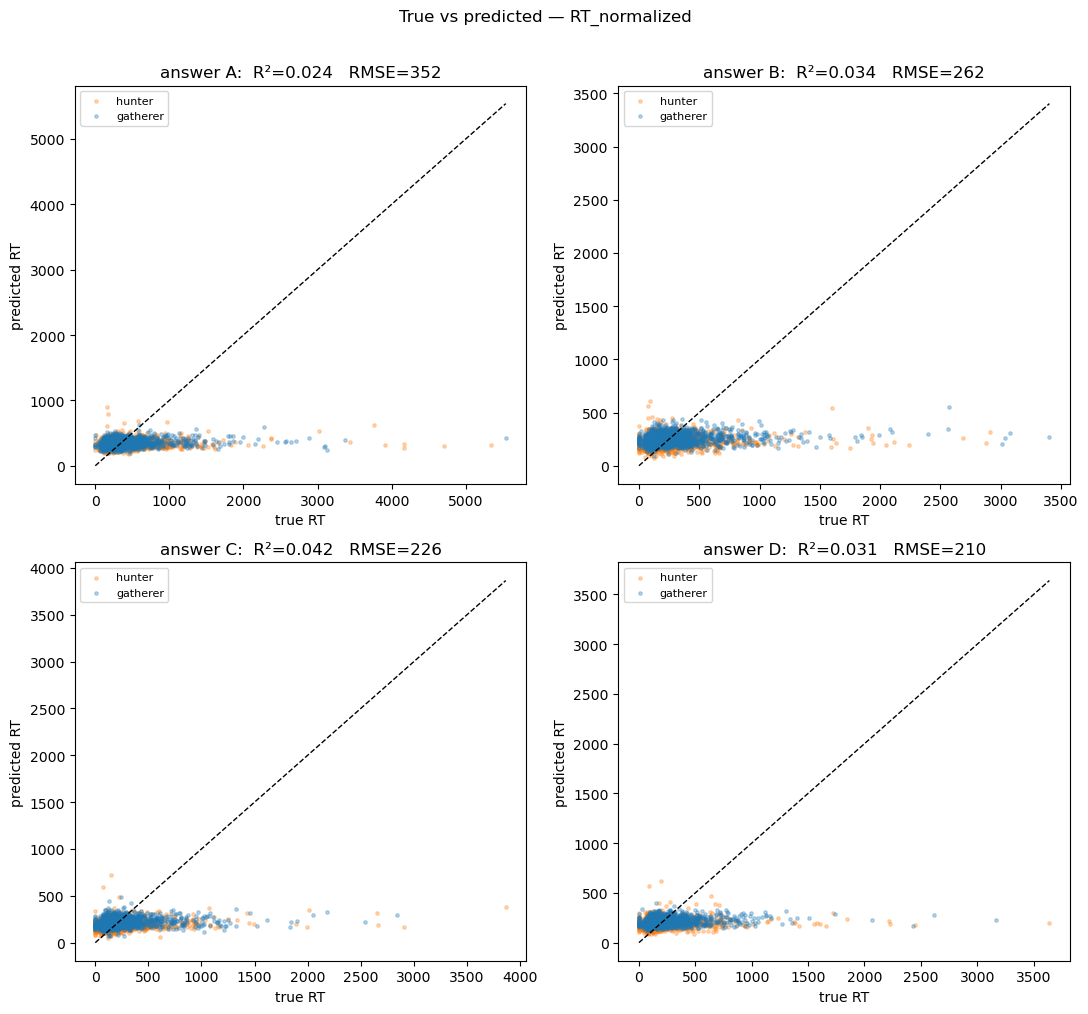

In [17]:
out_answer_rt = run_answer_rt_regression(
    model_df=answer_rt_model_df,
    feature_cols=FEATURE_COLS,
    rt_metric="RT_normalized",   # target: RT_normalized_answer_{A..D} ("RT_pure" also available)
    model_kind="ridge",          # "ridge" or "linear"
    alpha=1.0,
    test_size=0.2,
    random_state=42,
)

# per-answer held-out metrics
display(out_answer_rt["metrics"].round(3))

# coefficients and true/predicted
plot_coefs(out_answer_rt)
plot_true_pred(out_answer_rt)

## Trial-level paragraph reading features (lab's external extraction)

Runs the feature extraction taken from the lab's EyeBench / OneStop pipeline
(vendored in `src/external/EyeBench/`, constants in
`src/external/EyeBench/configs/constants.py`) on our paragraph reports, via the
adapter `src/external/EyeBench/paragraph_trial_features.py` — which also reproduces
their `OneStopProcessor` preprocessing step-for-step, since our reports are raw
where theirs are already processed.

One row per (`participant_id`, `TRIAL_INDEX`) trial, **1275 columns** with `RECONSTRUCT`
on (1240 without), each tagged by model family in the two
`*_trial_level_feature_keys.csv` files written alongside:

| family | n | what |
| --- | --- | --- |
| `RF` | 546 | every column of `numerical_ia_trial_columns` / `numerical_fixation_trial_columns` × 7 aggregations (mean/std/median/skew/kurtosis/max/min), prefixed `ia_feature_` / `fix_feature_` |
| `BEYELSTM` | 676 | gaze entropy (`fixation_feature_SGE` / `GTE`), fixation & word counts, and the 16 `gsf_features` averaged per word category → `<category>_<value>_<feature>` (`is_content_word`, `ptb_pos` = reduced POS `0.0`–`4.0` = FUNC/NOUN/VERB/ADJ/UNKNOWN, `entity_type`, `universal_pos`) |
| `SVM` | 9 | `skip_rate`, `num_of_fixations`, `mean_TFD`, `NEXT_SAC_*_mean/max` |
| `LOGISTIC` | 9 | `first_pass_skip_rate`, `mean_FFD/GD/TFD`, `mean_go_past_time`, `CURRENT_FIX_DURATION_mean`, `forward_saccade_length_mean`, `regression_rate` |
| `READING_SPEED` | 1 | `reading_speed` — words per **ms** (`PARAGRAPH_RT` is in ms) |

Practice and repeated-reading trials are dropped (as in `split_hunters_and_gatherers`);
`question_preview` (hunter = 1 / gatherer = 0) is attached for splitting later.

Three things to know before modelling:

- **~145 columns are constant zero.** Degenerate aggregations (`min` of count columns,
  spread of trial-constant columns like `PARAGRAPH_RT`), plus **all 80 `ptb_pos_*`
  columns** — in the source pipeline `ptb_pos` is mapped to numbers by
  `add_missing_features` and then mapped again per trial, yielding all-NaN and an
  empty grouping. `FIX_PTB_POS = True` gives them real values (function words 311 ms
  mean dwell vs. nouns 448).
- **23 of the `RECONSTRUCT` columns are exact duplicates** of features that already
  exist under our own column names (`ia_feature_*_landing_position` ==
  `ia_feature_*_IA_FIRST_RUN_LANDING_POSITION`, and likewise for
  `IA_FIRST_FIX_DURATION` / `IA_TOTAL_FIXATION_DURATION`). The 12 genuinely new ones
  are per-word saccade duration and peak velocity, aggregated from the fixation report.
- Words with no named entity are dropped from the `entity_type` grouping rather than
  forming a `NONE` category, as in the source.

The full build reads two multi-GB reports and takes ~1.5 h, so the result is cached at
`PARAGRAPH_TRIAL_FEATURES_PATH`. Use `QUICK_TEST` for a fast smoke run first.

In [18]:
from src.data_paths import (
    PARAGRAPH_TRIAL_FEATURES_DIR,
    PARAGRAPH_TRIAL_FEATURES_PATH,
)
from src.external.EyeBench.paragraph_trial_features import (
    build_paragraph_trial_level_features,
    load_paragraph_trial_level_features,
    save_paragraph_trial_level_features,
)

REBUILD = False   # True -> re-run the extraction even if the CSV already exists
QUICK_TEST = 0    # >0 -> only that many participants (a fast smoke run, not saved)
WITH_FIXATIONS = True  # False -> IA-only features (much faster, drops the fix_/gsf ones)

# False reproduces the source pipeline exactly, where the 80 ptb_pos_* columns come
# out all-zero because ptb_pos is mapped to numbers twice. True gives them real
# values. Nothing else differs between the two.
FIX_PTB_POS = True

# Fill IA columns their feature list wants but our report names differently or
# lacks (see reconstruct_source_columns): +35 columns, of which 23 duplicate
# existing ones exactly and 12 are new (per-word saccade duration / velocity).
RECONSTRUCT = True

build_kwargs = dict(
    include_fixation_features=WITH_FIXATIONS,
    fix_ptb_pos_double_mapping=FIX_PTB_POS,
    reconstruct_missing_columns=RECONSTRUCT,
)

if QUICK_TEST:
    participants = sorted(pd.read_csv(READY_ALL_FEATURES_PATH, usecols=["participant_id"])
                          ["participant_id"].unique())[:QUICK_TEST]
    trial_features = build_paragraph_trial_level_features(
        participants=participants, **build_kwargs
    )
elif REBUILD or not PARAGRAPH_TRIAL_FEATURES_PATH.exists():
    trial_features = save_paragraph_trial_level_features(**build_kwargs)
else:
    trial_features = load_paragraph_trial_level_features()

print("trial-level paragraph features:", trial_features.shape)

# What each feature belongs to (written by the extraction: RF / BEYELSTM / SVM /
# LOGISTIC / READING_SPEED).
feature_keys = pd.concat(
    [
        pd.read_csv(PARAGRAPH_TRIAL_FEATURES_DIR / name).assign(source=name.split("_")[0])
        for name in ("ia_trial_level_feature_keys.csv", "fixation_trial_level_feature_keys.csv")
        if (PARAGRAPH_TRIAL_FEATURES_DIR / name).exists()
    ],
    ignore_index=True,
)
display(feature_keys.groupby(["source", "feature_type"]).size().rename("n_features"))

trial_features.head()

trial-level paragraph features: (19438, 528)


source    feature_type 
fixation  BEYELSTM         596
          LOGISTIC           3
          RF               322
          SVM                6
ia        LOGISTIC           6
          READING_SPEED      1
          RF               259
          SVM                3
Name: n_features, dtype: int64

,participant_id,TRIAL_INDEX,fix_feature_mean_CURRENT_FIX_DURATION,fix_feature_std_CURRENT_FIX_DURATION,fix_feature_median_CURRENT_FIX_DURATION,fix_feature_skew_CURRENT_FIX_DURATION,fix_feature_kurtosis_CURRENT_FIX_DURATION,fix_feature_max_CURRENT_FIX_DURATION,fix_feature_min_CURRENT_FIX_DURATION,fix_feature_mean_CURRENT_FIX_PUPIL,...,ia_feature_min_IA_MIN_FIX_PUPIL_SIZE,skip_rate,num_of_fixations,mean_TFD,first_pass_skip_rate,mean_FFD,mean_GD,mean_go_past_time,reading_speed,question_preview
0,l10_202,3,180.557252,70.070102,175.0,1.294693,4.544828,501.0,25.0,928.839695,...,799.0,0.265060,131,284.975904,0.602410,187.852459,241.377049,274.081967,0.002689,0
1,l10_202,4,179.840659,63.160461,170.0,1.341336,5.359139,536.0,36.0,913.104396,...,796.0,0.248366,182,213.928105,0.411765,183.234783,215.486957,231.556522,0.003570,0
2,l10_202,6,164.600000,55.612567,162.0,1.106015,2.857553,395.0,48.0,871.341176,...,791.0,0.236842,85,184.092105,0.315789,165.672414,191.775862,209.465517,0.004186,0
3,l10_202,7,183.842520,62.567938,180.0,0.330660,0.227690,364.0,29.0,843.724409,...,703.0,0.254717,127,220.264151,0.556604,190.316456,220.658228,245.924051,0.003466,0
4,l10_202,8,190.385714,94.941379,174.0,2.591273,10.070930,722.0,27.0,857.500000,...,723.0,0.168831,348,430.629870,0.487013,186.085938,244.203125,266.867188,0.001777,0


In [19]:
trial_features

,participant_id,TRIAL_INDEX,fix_feature_mean_CURRENT_FIX_DURATION,fix_feature_std_CURRENT_FIX_DURATION,fix_feature_median_CURRENT_FIX_DURATION,fix_feature_skew_CURRENT_FIX_DURATION,fix_feature_kurtosis_CURRENT_FIX_DURATION,fix_feature_max_CURRENT_FIX_DURATION,fix_feature_min_CURRENT_FIX_DURATION,fix_feature_mean_CURRENT_FIX_PUPIL,...,ia_feature_min_IA_MIN_FIX_PUPIL_SIZE,skip_rate,num_of_fixations,mean_TFD,first_pass_skip_rate,mean_FFD,mean_GD,mean_go_past_time,reading_speed,question_preview
0,l10_202,3,180.557252,70.070102,175.0,1.294693,4.544828,501.0,25.0,928.839695,...,799.0,0.265060,131,284.975904,0.602410,187.852459,241.377049,274.081967,0.002689,0
1,l10_202,4,179.840659,63.160461,170.0,1.341336,5.359139,536.0,36.0,913.104396,...,796.0,0.248366,182,213.928105,0.411765,183.234783,215.486957,231.556522,0.003570,0
2,l10_202,6,164.600000,55.612567,162.0,1.106015,2.857553,395.0,48.0,871.341176,...,791.0,0.236842,85,184.092105,0.315789,165.672414,191.775862,209.465517,0.004186,0
3,l10_202,7,183.842520,62.567938,180.0,0.330660,0.227690,364.0,29.0,843.724409,...,703.0,0.254717,127,220.264151,0.556604,190.316456,220.658228,245.924051,0.003466,0
4,l10_202,8,190.385714,94.941379,174.0,2.591273,10.070930,722.0,27.0,857.500000,...,723.0,0.168831,348,430.629870,0.487013,186.085938,244.203125,266.867188,0.001777,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19433,l9_536,68,211.190476,64.009686,212.0,0.305566,-0.230834,406.0,93.0,835.133333,...,714.0,0.392857,105,197.991071,0.500000,215.441176,238.794118,268.867647,0.004449,1
19434,l9_536,69,200.174603,66.989348,200.0,0.404514,0.610639,408.0,28.0,858.111111,...,712.0,0.474227,63,130.010309,0.546392,199.941176,220.235294,234.019608,0.006676,1
19435,l9_536,70,201.826531,68.144209,189.0,0.655140,0.719233,424.0,72.0,832.591837,...,664.0,0.387755,98,201.826531,0.489796,215.500000,226.616667,237.150000,0.004304,1
19436,l9_536,71,219.938272,81.342948,222.0,0.695902,0.330007,484.0,78.0,871.382716,...,702.0,0.386364,81,202.443182,0.522727,229.018519,238.148148,259.481481,0.004324,1
